<div align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/58/Ufpb_brasao.svg/960px-Ufpb_brasao.svg.png" alt="UFPB Logo" width="80" style="margin-right: 20px;"/>
  <img src="https://i.ibb.co/XxDwtS8t/Logo-sem-fundo-ING.png" alt="LARHENA Logo" width="390"/>
</div>

# **Access and Processing Tutorial: UNIPLU-BR Database**

The **UNIPLU-BR** is a unified and standardized national database of point precipitation (non-interpolated) in Brazil. This dataset consolidates information from five primary monitoring networks:

* **CEMADEN:** National Center for Monitoring and Early Warning of Natural Disasters.
* **INMET:** National Institute of Meteorology.
* **ANA (Hidroweb):** National Water and Sanitation Agency.
* **Telemetria:** Hydrological monitoring telemetry system.
* **ICEA:** Institute of Air Space Control.

---

### **Contributions and Structure**
The database overcomes the fragmentation of Brazilian rainfall data through a rigorous curation process:
1. **Structural Standardization:** Harmonization of column names and attributes across different agencies.
2. **Time Zone Adjustment:** Standardization of timestamps based on geographical location (UTC offset).
3. **Temporal Resolution:** Records ranging from 10-minute intervals to daily resolution.

> **Quality Disclaimer:** The processing of this dataset is strictly focused on **structural standardization**. No physical consistency checks or outlier filtering were performed. Rainfall values remain as originally reported by the agencies.

---

### **Notebook Objectives**
1. **Access:** Loading and handling data tables and metadata.
2. **Consolidation:** Unifying multiple states and time periods.
3. **Processing:** Converting sub-daily data to daily resolution.
4. **Analysis:** Filtering, plotting, and calculating monthly and annual rainfall statistics.
5. **Export:** Saving results in interoperable formats (Excel/CSV).

---

**Data Sources:**
* **CEMADEN:** [gov.br/cemaden](https://www.gov.br/cemaden/pt-br)
* **INMET:** [portal.inmet.gov.br](https://portal.inmet.gov.br/)
* **ANA (Hidroweb/Telemetry):** [snirh.gov.br/hidroweb](https://www.snirh.gov.br/hidroweb/serieshistoricas)
* **ICEA:** [pesquisa.icea.decea.mil.br](https://pesquisa.icea.decea.mil.br/)



**Citation:** 
* **Das Neves Almeida, C.**, Francis Bertrand, G., Carvalho Lemos, F., da Silva Freitas, E., Lins Silva, A., Vidal Barbosa, J. L., ... & Coelho, V. H. R. (2025). The design of the Brazilian Sub-Daily Rainfall dataset (BR-SDR): two decades of high-time-resolution data in Brazil. *Hydrological Sciences Journal*, 70(11), 1850-1862. https://doi.org/10.1080/02626667.2025.2506193

* **Lemos, F. C.**, Freitas, E. S., Coelho, V. H. R., Reis Júnior, D. S., Patriota, E. G., Meira, M. A., Vidal-Barbosa, J. L., Claudino, C. M. A., Silva, G. S., Nascimento, D. C., Ramos Filho, G. M., Cunha, A. P. M. A., Alves, L. G. S., Zeri, L. M. M., Ribeiro Neto, G. G., Bertrand, G. F., Tomasella, J., Souza, S. A., Araújo, A. A., Rampinelle, C. G., & Almeida, C. N. (2026). Unified Brazilian Rainfall Dataset (UNIPLU-BR): A Standardized National Database of Point Precipitation from Major Brazilian Monitoring Networks [Data set]. *Zenodo*. https://doi.org/10.5281/zenodo.18883358

**Lead Institution:**
* Federal University of Paraíba (**UFPB**)
    * Laboratory of Water Resources and Environmental Engineering (**LARHENA**)
    * Graduate Program in Civil and Environmental Engineering (**PPGECAM**)
* Federal Institute of Paraíba (**IFPB**)

**Partner Institutions:**
* National Center for Monitoring and Early Warning of Natural Disasters (**CEMADEN**)
* University of Brasília (**UnB**)
* National Water and Sanitation Agency (**ANA**)
* Université de Franche-Comté (**UFC**)


**Contacts:**
* **Cristiano das Neves Almeida** (Coordinator - UFPB): [almeida74br@yahoo.com.br](mailto:almeida74br@yahoo.com.br) | [Lattes](https://lattes.cnpq.br/5858373824027435)
* **Filipe Carvalho Lemos** (Database Structuring - UFPB): [filipe_carvalho_l@hotmail.com](mailto:filipe_carvalho_l@hotmail.com) | [Lattes](https://lattes.cnpq.br/5359782978523771)
* **Emerson da Silva Freitas** (Reviewer - IFPB): [emerson.sfreitas@hotmail.com](mailto:emerson.sfreitas@hotmail.com) | [Lattes](https://lattes.cnpq.br/2175020020907001)

**Last Update:** March 10, 2026

---

### **⚠️ Configuration Note: Setting the Database Directory**

Before running the script, the user must manually update the **local directory path** to point to the folder where the **UNIPLU-BR** database is stored. 

Find the variable `path` in the code blocks and adjust it according to your operating system's file structure. For example:

* **Windows:** `C:/Users/Name/Documents/UNIPLU-BR/`
* **Linux/Mac:** `/home/user/data/UNIPLU-BR/`

Make sure all required `.zip` files (e.g., `SP_2024.zip`) are located within this specified directory to ensure the functions can locate and extract the data correctly.

---

## 1. Library Imports

In [1]:
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Function for Reading ZIP Files

The data is stored in `.parquet` format within `.zip` archives. The function below facilitates direct extraction into memory, avoiding the need to manually unzip files on your local disk.

In [2]:
def read_UNIPLU_BR(zip_path, table='table_data'):
    """
    Reads a table ('table_data' or 'table_info') from a UNIPLU-BR ZIP archive.
    
    Parameters:
    zip_path (str): Path to the .zip file.
    table (str): The specific table to extract ('table_data' for rainfall or 'table_info' for metadata).
    
    Returns:
    pd.DataFrame: Extracted data as a pandas DataFrame.
    """
    parquet_file = f"{table}.parquet"
    try:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            with zf.open(parquet_file) as f:
                df = pd.read_parquet(f)
        return df
    except FileNotFoundError:
        print(f"Error: File {zip_path} not found.")
        return pd.DataFrame()
    except KeyError:
        print(f"Error: {parquet_file} not found inside the ZIP archive.")
        return pd.DataFrame()

## 3. Opening and Verifying the Data

In this section, we load the dataset for a specific state (e.g., São Paulo) and inspect the data types and structure of each column to ensure the information is ready for analysis.

In [4]:
# Path to the dataset (adjust to your local directory)
path = './2 - UNIPLU_BR/SP_2024.zip' 

# Loading rainfall and metadata tables
df_rainfall = read_UNIPLU_BR(path, 'table_data')
df_info = read_UNIPLU_BR(path, 'table_info')

# Checking data types
print("Rainfall table data types:")
print(df_rainfall.dtypes)

# Displaying metadata table
df_info

Rainfall table data types:
gauge_code            object
rain_mm              float64
datetime      datetime64[ns]
dtype: object


,gauge_code,city,state,lat,long,time_step,elevation,UTC,network,responsible
0,A701,Sao Paulo - Mirante,SP,-23.496289,-46.620067,60,785.64,-3.0,INMET subdiário,INMET
1,A705,Bauru,SP,-22.358056,-49.028889,60,636.17,-3.0,INMET subdiário,INMET
2,A706,Campos do Jordao,SP,-22.750278,-45.603889,60,1662.95,-3.0,INMET subdiário,INMET
3,A707,Presidente Prudente,SP,-22.120000,-51.408611,60,431.92,-3.0,INMET subdiário,INMET
4,A708,Franca,SP,-20.584444,-47.382500,60,1002.74,-3.0,INMET subdiário,INMET
...,...,...,...,...,...,...,...,...,...,...
1114,2448017,Iporanga,SP,-24.585600,-48.594700,1440,61.00,-3.0,Hidroweb diário,SGB-CPRM
1115,2448018,Eldorado,SP,-24.600000,-48.216700,1440,40.00,-3.0,Hidroweb diário,DAEE-SP
1116,2448024,Cajati,SP,-24.716700,-48.116700,1440,50.00,-3.0,Hidroweb diário,DAEE-SP
1117,2448026,Barra do Turvo,SP,-24.750000,-48.500000,1440,160.00,-3.0,Hidroweb diário,DAEE-SP


## 4. Loading Multiple States and Years

If your analysis requires a long historical series or data from multiple states simultaneously, you can use the following approach to iterate through files and consolidate them into a single dataset.

In [ ]:
states = ['RS', 'SC']
years = [2023, 2024]

# Create two lists to store the different types of tables
data_list = []
info_list = []

for state in states:
    for year in years:
        file_path = f'./2 - UNIPLU-BR/{state}_{year}.zip'
        
        # Loading the rainfall data table
        temp_data_df = read_UNIPLU_BR(file_path, 'table_data')
        if not temp_data_df.empty:
            data_list.append(temp_data_df)
        
        # Loading the information table (metadata)
        temp_info_df = read_UNIPLU_BR(file_path, 'table_info')
        if not temp_info_df.empty:
            info_list.append(temp_info_df)

# Consolidate all rainfall data
df_total_data = pd.concat(data_list, ignore_index=True)

# Consolidate station information and remove duplicates 
# (as the same station may appear across different years)
df_total_info = pd.concat(info_list, ignore_index=True).drop_duplicates(subset=['gauge_code'])

print(f"Total rainfall records loaded: {len(df_total_data)}")
print(f"Total unique stations mapped: {len(df_total_info)}")

Total rainfall records loaded: 19336202
Total unique stations mapped: 1412


## 5. Processing: From Sub-daily to Daily Resolution

Many hydrological and climatological analyses require daily accumulated rainfall (24-hour totals). In this section, we convert the high-resolution data (e.g., 10-minute or hourly) into daily totals using the `resample` method in Pandas.

In [9]:
# 1. Identify station codes for the CEMADEN network
# Network information is located in the df_total_info table
cemaden_codes = df_total_info[df_total_info['network'] == 'CEMADEN']['gauge_code'].unique()

# 2. Filter rainfall data for these specific stations
df_cemaden = df_total_data[df_total_data['gauge_code'].isin(cemaden_codes)].copy()

# 3. Perform daily accumulation (Standard 09h-09h / 12h-12h UTC)
# We apply resampling with a 12h offset and right-closed intervals
df_cemaden_daily = (
    df_cemaden.set_index('datetime') # or 'datetime'
    .groupby('gauge_code')['rain_mm']
    .resample('24h', offset='12h', closed='right')
    .sum()
    .reset_index()
)

# 4. Apply Shift so the accumulated rainfall is assigned to the correct reading date
# In hydrology, the 24h total is usually recorded on the day the gauge is emptied
df_cemaden_daily['rain_mm'] = df_cemaden_daily.groupby('gauge_code')['rain_mm'].shift(1)

# Remove potential null values generated by the shift
df_cemaden_daily = df_cemaden_daily.dropna(subset=['rain_mm'])

print(f"Daily accumulation completed for the CEMADEN network.")
df_cemaden_daily

Daily accumulation completed for the CEMADEN network.


,gauge_code,datetime,rain_mm
1,420010101A,2023-01-02 12:00:00,9.4
2,420010101A,2023-01-03 12:00:00,0.6
3,420010101A,2023-01-04 12:00:00,36.8
4,420010101A,2023-01-05 12:00:00,0.0
5,420010101A,2023-01-06 12:00:00,0.0
...,...,...,...
325803,432300206A,2024-01-11 12:00:00,0.0
325804,432300206A,2024-01-12 12:00:00,0.0
325805,432300206A,2024-01-13 12:00:00,0.0
325806,432300206A,2024-01-14 12:00:00,0.0


## 6. Filtering and Visualization

In this section, we filter a specific station from the processed dataset to generate a rainfall plot (Hyetograph). Visual inspection is a key step to identify seasonal patterns and verify the results of the daily accumulation process.

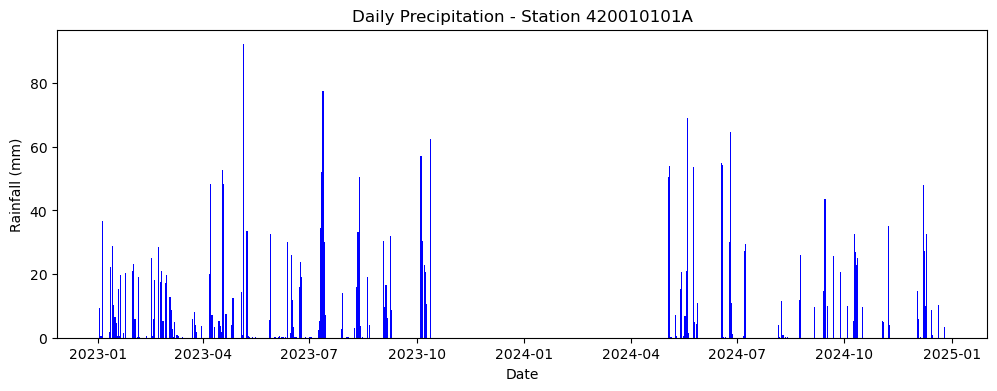

In [12]:
# Selecting the first available station code
example_code = df_cemaden_daily['gauge_code'].iloc[0]
station_filter = df_cemaden_daily[df_cemaden_daily['gauge_code'] == example_code]

# Plotting daily rainfall
plt.figure(figsize=(12, 4))
plt.bar(station_filter['datetime'], station_filter['rain_mm'], color='blue', width=1)

# Formatting title and labels
plt.title(f'Daily Precipitation - Station {example_code}')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.show()

## 7. Monthly and Annual Aggregation

In this section, we aggregate the daily rainfall data into monthly and annual totals. These statistics are essential for characterizing local climatology, identifying seasonal patterns, and conducting long-term water balance studies.

In [13]:
# Extracting month and year from the datetime column
df_cemaden_daily['month'] = df_cemaden_daily['datetime'].dt.month
df_cemaden_daily['year'] = df_cemaden_daily['datetime'].dt.year

# Calculating monthly totals per station and year
monthly_rainfall = df_cemaden_daily.groupby(['gauge_code', 'year', 'month'])['rain_mm'].sum().reset_index()

# Calculating annual totals per station
annual_rainfall = df_cemaden_daily.groupby(['gauge_code', 'year'])['rain_mm'].sum().reset_index()

print("Monthly Rainfall Summary:")
print(monthly_rainfall.head())

print("\nAnnual Rainfall Summary:")
print(annual_rainfall.head())

Monthly Rainfall Summary:
   gauge_code  year  month  rain_mm
0  420010101A  2023      1    222.8
1  420010101A  2023      2    185.2
2  420010101A  2023      3     54.6
3  420010101A  2023      4    214.2
4  420010101A  2023      5    180.2

Annual Rainfall Summary:
   gauge_code  year  rain_mm
0  420010101A  2023   1654.2
1  420010101A  2024   1117.2
2  420010102A  2023    108.8
3  420010102A  2024     55.4
4  420010103A  2023      7.0


## 8. Data Export

In this final section, we save the processed and aggregated results for external use. These files can be easily imported into spreadsheets (Excel), GIS software (ArcGIS Pro), or hydraulic modeling tools.

In [ ]:
# 1. Exporting Monthly Rainfall to CSV and Excel
monthly_rainfall.to_csv('UNIPLU_BR_monthly_rainfall.csv', index=False)
monthly_rainfall.to_excel('UNIPLU_BR_monthly_rainfall.xlsx', index=False)

# 2. Exporting Annual Rainfall to CSV
annual_rainfall.to_csv('UNIPLU_BR_annual_rainfall.csv', index=False)

# 3. Exporting the filtered Daily data (specific for analysis/plotting)
df_cemaden_daily.to_csv('UNIPLU_BR_daily_processed.csv', index=False)

print("Export completed successfully.")
print("Files generated: CSV and Excel formats.")